In [10]:
# =====================================================
# ASSIGNMENT 9 - Data Analytics II
# Logistic Regression - Social Network Ads
# =====================================================

# STEP 1: Import Libraries\
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

In [2]:
# STEP 2: Load Dataset
# Download from: https://www.kaggle.com/datasets/rakeshrau/social-network-ads
# Save as Social_Network_Ads.csv in same folder
df = pd.read_csv('Social_Network_Ads.csv')
print("Dataset Loaded!")
print(df.head())
print("Shape:", df.shape)

Dataset Loaded!
    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0
Shape: (400, 5)


In [3]:
# STEP 3: Select Features and Target
X = df[['Age', 'EstimatedSalary']]   # Input
Y = df['Purchased']                   # Output (0 or 1)

# STEP 4: Train Test Split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [4]:
    # STEP 5: Feature Scaling (important for Logistic Regression!)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [5]:
# STEP 6: Train Model
model = LogisticRegression()
model.fit(X_train, Y_train)
print("\nModel Trained!")

# STEP 7: Predict
Y_pred = model.predict(X_test)


Model Trained!


In [6]:
# =====================================================
# STEP 8: Confusion Matrix
# =====================================================
cm = confusion_matrix(Y_test, Y_pred)
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[50  2]
 [ 9 19]]


In [7]:
# Extract TP, TN, FP, FN
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

print("\nTP (True Positive) :", TP)
print("TN (True Negative) :", TN)
print("FP (False Positive):", FP)
print("FN (False Negative):", FN)


TP (True Positive) : 19
TN (True Negative) : 50
FP (False Positive): 2
FN (False Negative): 9


In [8]:
# =====================================================
# STEP 9: Calculate All Metrics
# =====================================================
accuracy  = (TP + TN) / (TP + TN + FP + FN)
error     = 1 - accuracy
precision = TP / (TP + FP)
recall    = TP / (TP + FN)

print("\n--- Model Performance ---")
print("Accuracy  :", round(accuracy, 2))
print("Error Rate:", round(error, 2))
print("Precision :", round(precision, 2))
print("Recall    :", round(recall, 2))


--- Model Performance ---
Accuracy  : 0.86
Error Rate: 0.14
Precision : 0.9
Recall    : 0.68


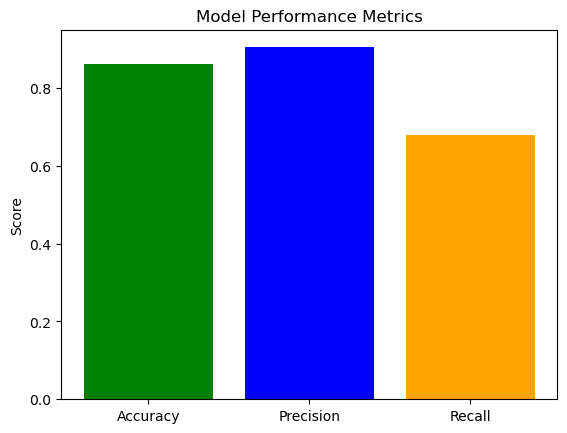

In [11]:
# STEP 10: Simple Bar Plot of Metrics
metrics = ['Accuracy', 'Precision', 'Recall']
values  = [accuracy, precision, recall]

plt.bar(metrics, values, color=['green', 'blue', 'orange'])
plt.title("Model Performance Metrics")
plt.ylabel("Score")
plt.show()